# Plot alpha and beta curves from MLflow evaluations

Set `TARGET_FOLDER` to an experiment folder inside `mlruns` (for example `mlruns/6`).
The notebook will search recursively for every `evaluation.txt` file under that folder and plot the alpha and beta curves for each run.

In [1]:
from __future__ import annotations

import ast
import json
from pathlib import Path

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

In [3]:
TARGET_FOLDER = Path('../mlruns/6')

if not TARGET_FOLDER.exists():
    raise FileNotFoundError(f'Folder not found: {TARGET_FOLDER.resolve()}')

TARGET_FOLDER.resolve()

PosixPath('/Users/sarakhan/Projects/Uni/Gen-Trees/mlruns/6')

In [4]:
def parse_curve_line(text: str, label: str) -> list[float]:
    prefix = f'{label}:'
    for raw_line in text.splitlines():
        line = raw_line.strip()
        if line.startswith(prefix):
            return ast.literal_eval(line.split(':', 1)[1].strip())
    raise ValueError(f'Missing {label} in evaluation file')


def load_run_label(evaluation_file: Path) -> str:
    metadata_file = evaluation_file.with_name('run_metadata.json')
    if metadata_file.exists():
        metadata = json.loads(metadata_file.read_text())
        run_name = metadata.get('run_name')
        model_name = metadata.get('model_name')
        if run_name and model_name:
            return f'{run_name} ({model_name})'
        if run_name:
            return run_name
        if model_name:
            return model_name
    return evaluation_file.parents[2].name


def load_curves(base_folder: Path) -> list[dict]:
    runs = []
    for evaluation_file in sorted(base_folder.rglob('evaluation.txt')):
        text = evaluation_file.read_text()
        runs.append(
            {
                'label': load_run_label(evaluation_file),
                'run_id': evaluation_file.parents[2].name,
                'path': evaluation_file,
                'alpha_grid': parse_curve_line(text, 'Alpha grid'),
                'p_alpha': parse_curve_line(text, 'P_alpha curve'),
                'beta_grid': parse_curve_line(text, 'Beta grid'),
                'r_beta': parse_curve_line(text, 'R_beta curve'),
            }
        )
    if not runs:
        raise FileNotFoundError(f'No evaluation.txt files found under {base_folder.resolve()}')
    return runs


runs = load_curves(TARGET_FOLDER)
len(runs)

6

In [5]:
for run in runs:
    print(f"{run['label']}: {run['path']}")

ibm_hr_GenForest (GenForest): ../mlruns/6/1e1868527f0645a6bd3238c22c78c18b/artifacts/evaluation/evaluation.txt
ibm_hr_TVAE (TVAE): ../mlruns/6/5b46f016a9aa4a1caa626f3d6ebd5e95/artifacts/evaluation/evaluation.txt
ibm_hr_TabDDM (TabDDM): ../mlruns/6/611c979034fe4b95be00d03d0cf77294/artifacts/evaluation/evaluation.txt
ibm_hr_arf (arf): ../mlruns/6/64a725b5b77f4f0588f7a7aeb493e119/artifacts/evaluation/evaluation.txt
ibm_hr_CTGAN (CTGAN): ../mlruns/6/96081a3142b54550964647cd421b5a4c/artifacts/evaluation/evaluation.txt
ibm_hr_GaussianCopula (GaussianCopula): ../mlruns/6/c49d50dcda0640deaf97ae605f64831d/artifacts/evaluation/evaluation.txt


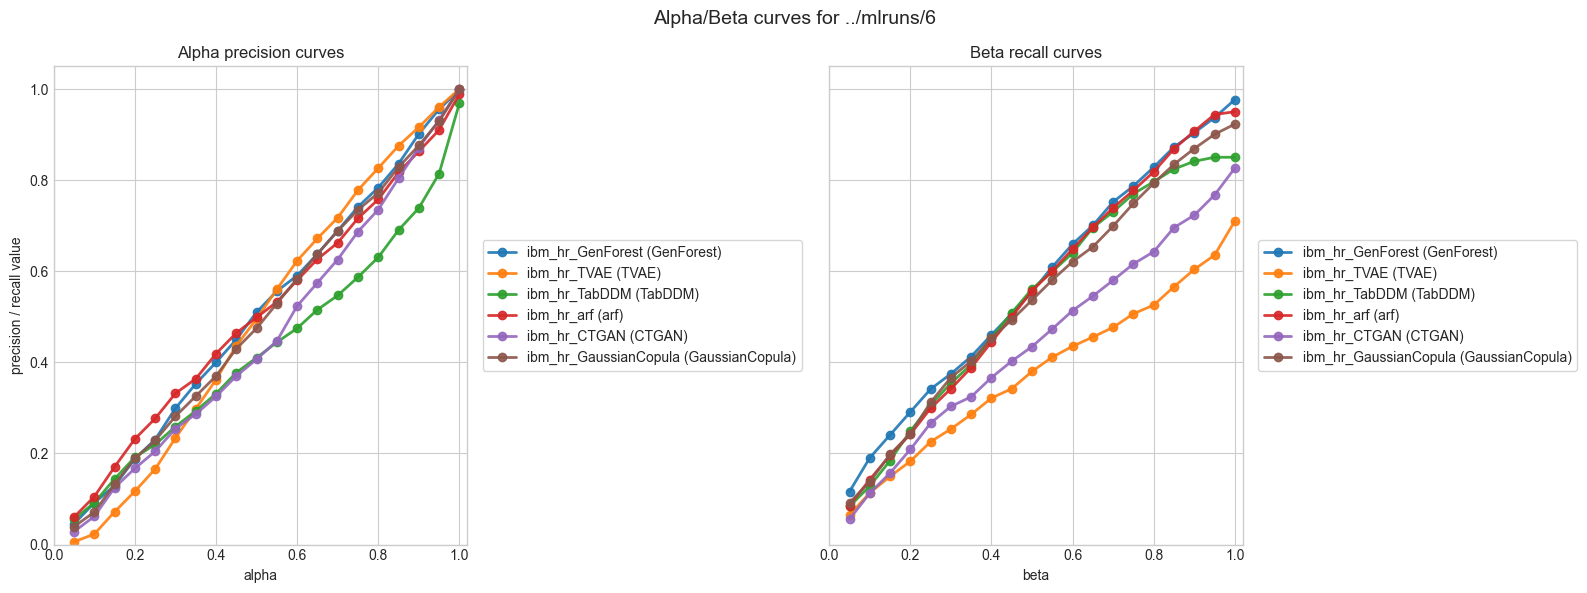

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for run in runs:
    axes[0].plot(run['alpha_grid'], run['p_alpha'], marker='o', linewidth=2, alpha=0.9, label=run['label'])
    axes[1].plot(run['beta_grid'], run['r_beta'], marker='o', linewidth=2, alpha=0.9, label=run['label'])

axes[0].set_title('Alpha precision curves')
axes[0].set_xlabel('alpha')
axes[0].set_ylabel('precision / recall value')

axes[1].set_title('Beta recall curves')
axes[1].set_xlabel('beta')

for ax in axes:
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.05)
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True)

fig.suptitle(f'Alpha/Beta curves for {TARGET_FOLDER}', fontsize=14)
fig.tight_layout()
plt.show()

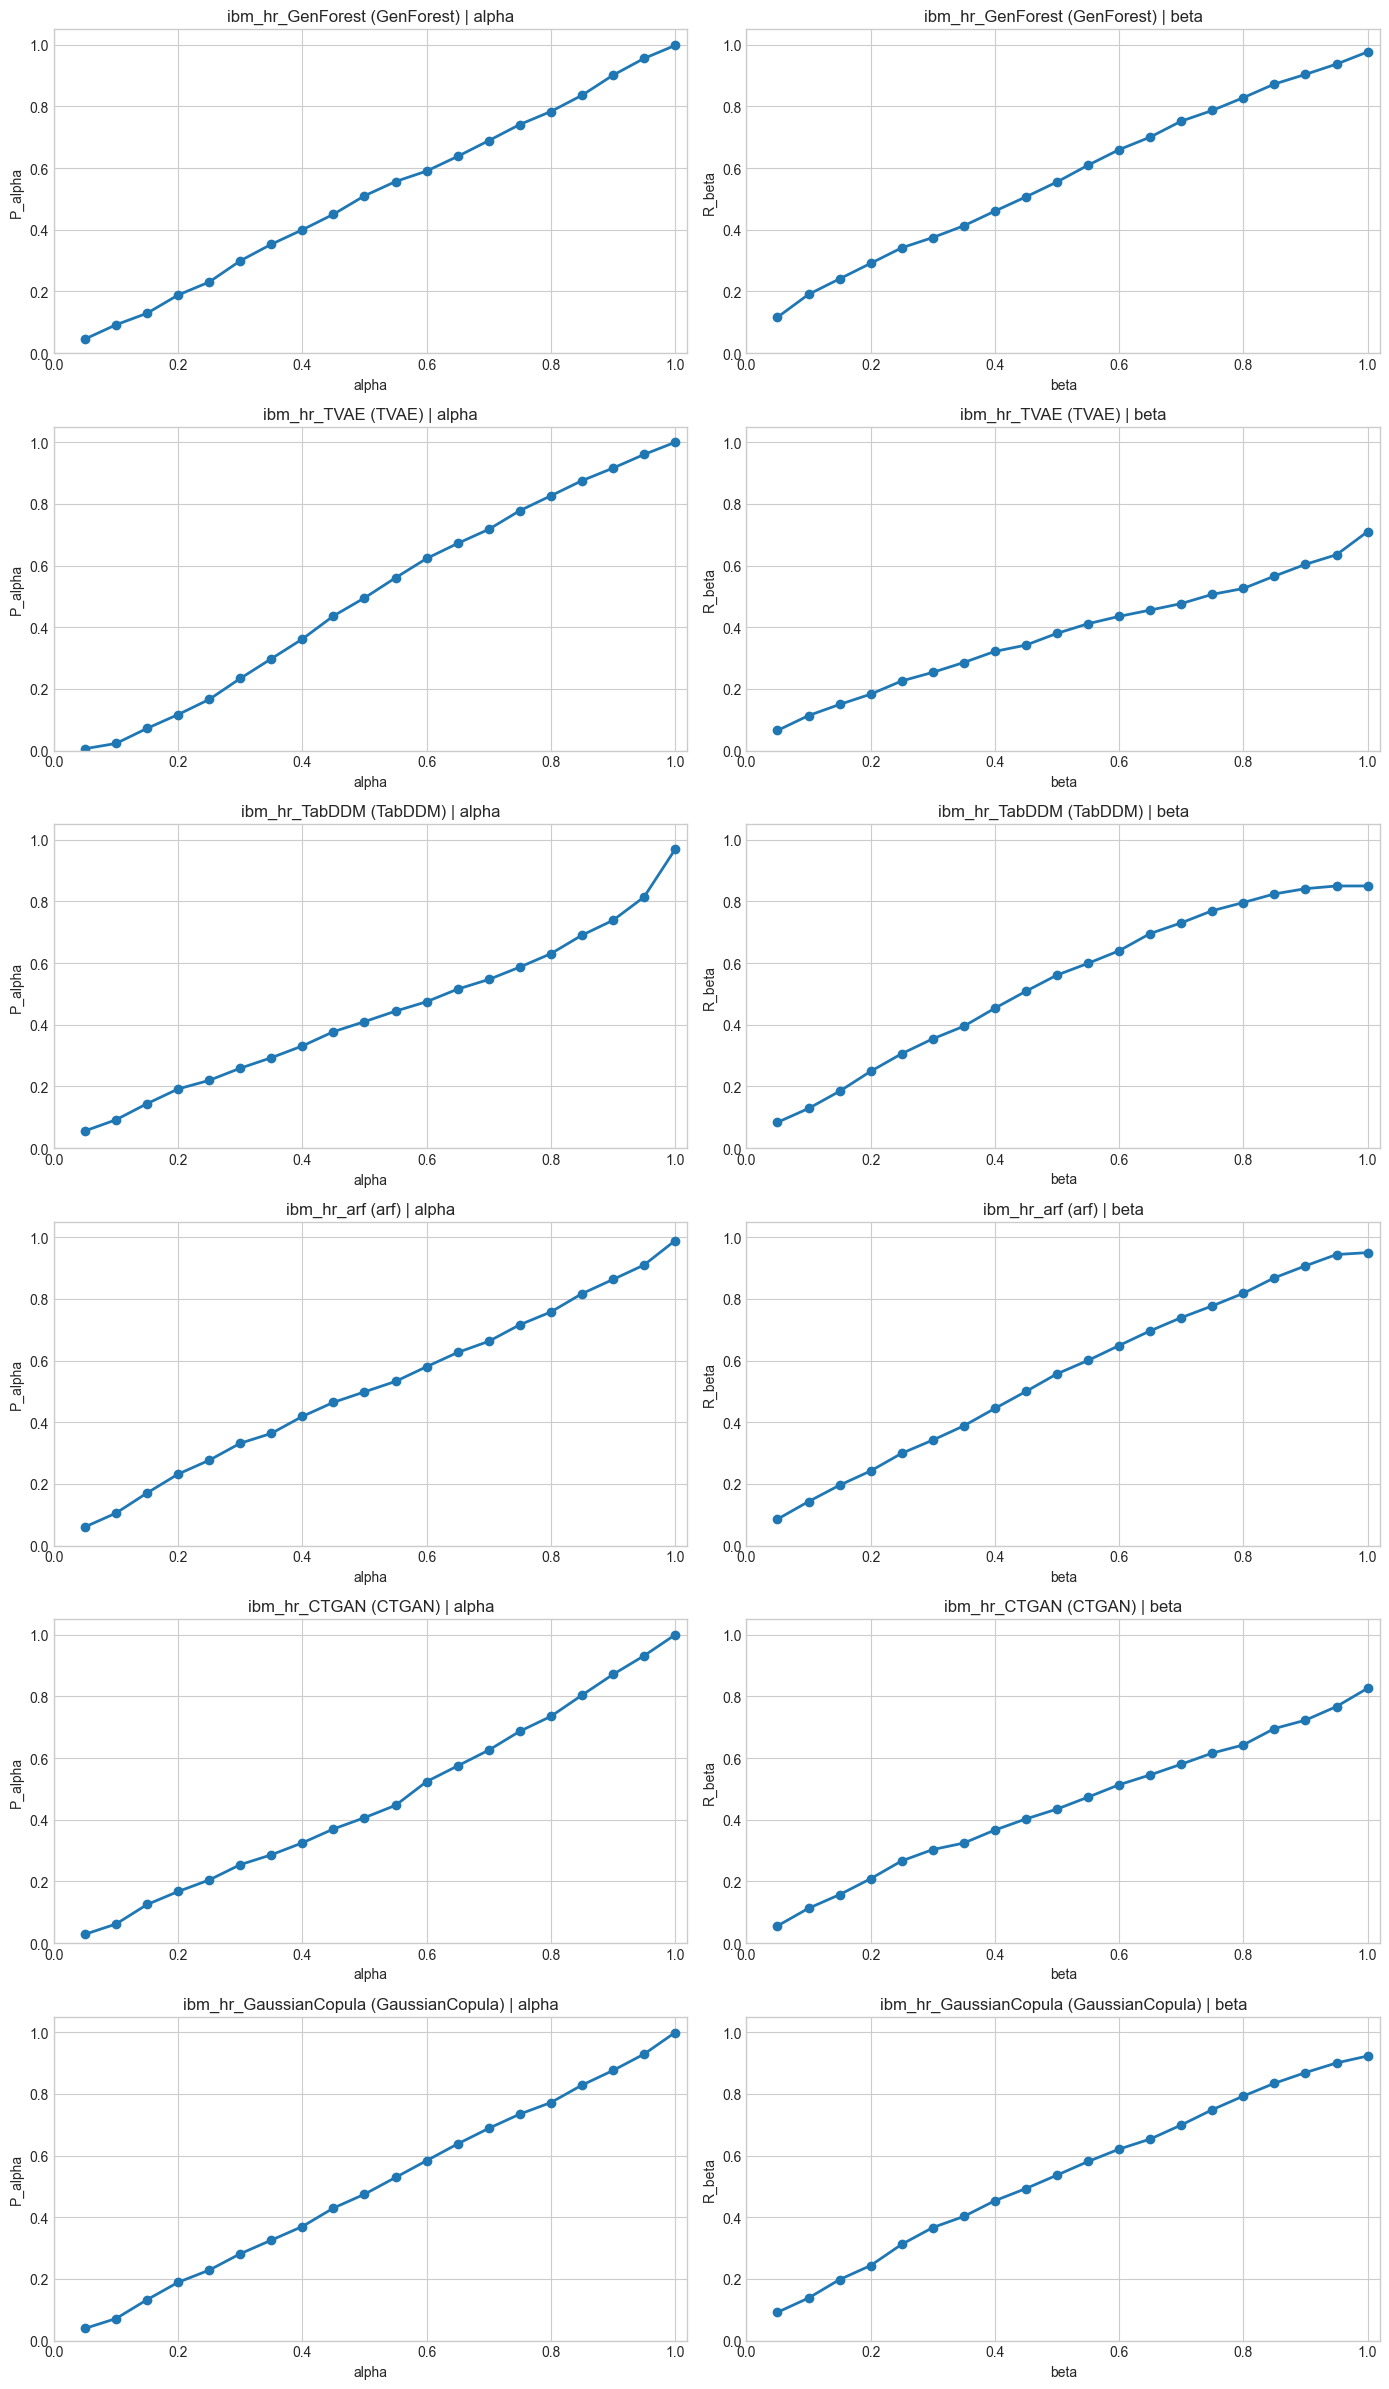

In [7]:
fig, axes = plt.subplots(len(runs), 2, figsize=(14, max(4 * len(runs), 6)), squeeze=False)

for row, run in enumerate(runs):
    axes[row, 0].plot(run['alpha_grid'], run['p_alpha'], marker='o', linewidth=2)
    axes[row, 0].set_title(f"{run['label']} | alpha")
    axes[row, 0].set_xlim(0, 1.02)
    axes[row, 0].set_ylim(0, 1.05)
    axes[row, 0].set_xlabel('alpha')
    axes[row, 0].set_ylabel('P_alpha')

    axes[row, 1].plot(run['beta_grid'], run['r_beta'], marker='o', linewidth=2)
    axes[row, 1].set_title(f"{run['label']} | beta")
    axes[row, 1].set_xlim(0, 1.02)
    axes[row, 1].set_ylim(0, 1.05)
    axes[row, 1].set_xlabel('beta')
    axes[row, 1].set_ylabel('R_beta')

fig.tight_layout()
plt.show()